# 02 - Factor Research

This notebook reviews factor diagnostics generated by the main pipeline. It reads IC reports from `reports/` and does not recompute core factor logic.

## Current Factor Definitions

- Momentum: $\log(\frac{P_{t-skip}}{P_{t-lookback}})$. The original default is 12-1 momentum: `lookback_days=252`, `skip_days=21`.
- Low volatility: negative annualized rolling volatility of returns, so lower-volatility stocks receive higher scores.
- Short-term reversal: negative recent 1-month log return.
- Composite: equal-weight combination of cross-sectionally z-scored factors, standardized again cross-sectionally.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

REPORTS = PROJECT_ROOT / "reports"

def read_report_csv(filename):
    path = REPORTS / filename
    if not path.exists():
        raise FileNotFoundError(f"Run python main.py first. Missing: {path}")
    return pd.read_csv(path)

## Load IC Reports

In [2]:
factor_ic = read_report_csv("factor_ic_summary.csv")
factor_ic_subperiod = read_report_csv("factor_ic_subperiod.csv")
momentum_ic = read_report_csv("momentum_ic_sensitivity.csv")

display(factor_ic)
display(factor_ic_subperiod.head())
display(momentum_ic)

,factor,mean_ic,std_ic,icir,hit_rate,count,mean_rank_ic,rank_icir,rank_hit_rate
0,momentum,0.011951,0.202383,0.059053,0.552000,125.0,-0.000432,-0.002201,0.528000
1,lowvol,-0.070379,0.260164,-0.270517,0.381679,131.0,-0.033530,-0.139192,0.427481
2,reversal,-0.008145,0.168431,-0.048355,0.441176,136.0,0.001633,0.009793,0.500000
3,composite,-0.017442,0.205082,-0.085051,0.488000,125.0,-0.013237,-0.065297,0.480000


,factor,period,mean_ic,icir,hit_rate,mean_rank_ic,rank_icir,rank_hit_rate,count
0,momentum,2015_2019,-0.022902,-0.107872,0.437500,-0.024039,-0.111375,0.416667,48.0
1,momentum,2020_2022,0.003611,0.017076,0.583333,-0.015725,-0.076496,0.527778,36.0
2,momentum,2023_latest,0.060078,0.341307,0.658537,0.040634,0.257004,0.658537,41.0
3,lowvol,2015_2019,-0.057933,-0.280013,0.351852,-0.023079,-0.101342,0.444444,54.0
4,lowvol,2020_2022,-0.035601,-0.115727,0.500000,-0.030424,-0.112071,0.444444,36.0


,lookback_days,skip_days,mean_ic,std_ic,icir,hit_rate,count,mean_rank_ic,rank_icir,rank_hit_rate
0,63,0,0.003884,0.192640,0.020162,0.522388,134.0,-0.002814,-0.015321,0.500000
1,63,21,-0.005637,0.179357,-0.031430,0.507463,134.0,-0.007369,-0.042029,0.485075
2,126,0,0.018023,0.194569,0.092630,0.557252,131.0,0.007639,0.041203,0.526718
3,126,21,0.014165,0.183931,0.077012,0.519084,131.0,0.003396,0.018953,0.480916
4,189,0,0.017025,0.212130,0.080259,0.562500,128.0,0.006093,0.030421,0.539062
5,189,21,0.014764,0.203012,0.072724,0.539062,128.0,0.003705,0.019083,0.515625
6,252,0,0.013437,0.212499,0.063235,0.544000,125.0,0.000465,0.002296,0.536000
7,252,21,0.011951,0.202383,0.059053,0.552000,125.0,-0.000432,-0.002201,0.528000


## Sort Factors by IC and Rank IC

In [3]:
display(factor_ic.sort_values("mean_ic", ascending=False))
display(factor_ic.sort_values("mean_rank_ic", ascending=False))

,factor,mean_ic,std_ic,icir,hit_rate,count,mean_rank_ic,rank_icir,rank_hit_rate
0,momentum,0.011951,0.202383,0.059053,0.552000,125.0,-0.000432,-0.002201,0.528000
2,reversal,-0.008145,0.168431,-0.048355,0.441176,136.0,0.001633,0.009793,0.500000
3,composite,-0.017442,0.205082,-0.085051,0.488000,125.0,-0.013237,-0.065297,0.480000
1,lowvol,-0.070379,0.260164,-0.270517,0.381679,131.0,-0.033530,-0.139192,0.427481


,factor,mean_ic,std_ic,icir,hit_rate,count,mean_rank_ic,rank_icir,rank_hit_rate
2,reversal,-0.008145,0.168431,-0.048355,0.441176,136.0,0.001633,0.009793,0.500000
0,momentum,0.011951,0.202383,0.059053,0.552000,125.0,-0.000432,-0.002201,0.528000
3,composite,-0.017442,0.205082,-0.085051,0.488000,125.0,-0.013237,-0.065297,0.480000
1,lowvol,-0.070379,0.260164,-0.270517,0.381679,131.0,-0.033530,-0.139192,0.427481


## Factor IC Bar Plots

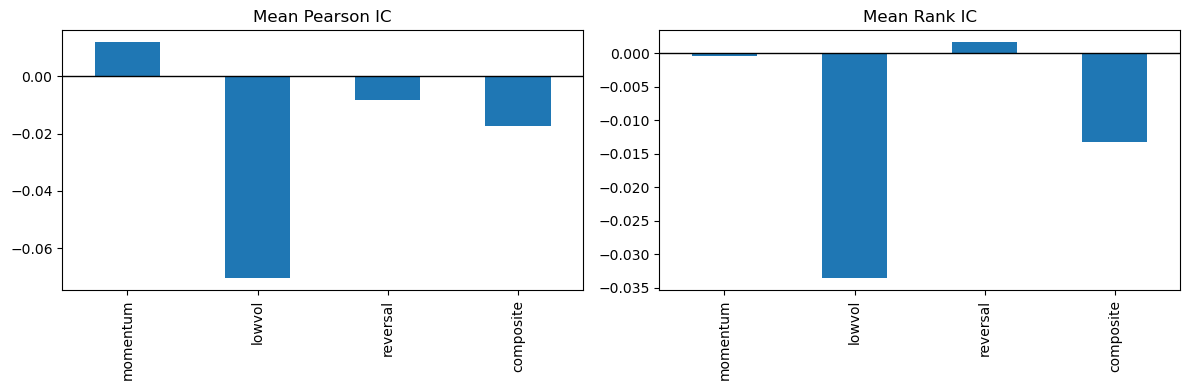

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

factor_ic.set_index("factor")["mean_ic"].plot(kind="bar", ax=axes[0], title="Mean Pearson IC")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_xlabel("")

factor_ic.set_index("factor")["mean_rank_ic"].plot(kind="bar", ax=axes[1], title="Mean Rank IC")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()

## Momentum Parameter Sensitivity

In [5]:
display(momentum_ic.sort_values("mean_ic", ascending=False))

mean_ic_pivot = momentum_ic.pivot(index="lookback_days", columns="skip_days", values="mean_ic")
rank_ic_pivot = momentum_ic.pivot(index="lookback_days", columns="skip_days", values="mean_rank_ic")

print("Mean Pearson IC by momentum parameters")
display(mean_ic_pivot)

print("Mean Rank IC by momentum parameters")
display(rank_ic_pivot)

,lookback_days,skip_days,mean_ic,std_ic,icir,hit_rate,count,mean_rank_ic,rank_icir,rank_hit_rate
2,126,0,0.018023,0.194569,0.092630,0.557252,131.0,0.007639,0.041203,0.526718
4,189,0,0.017025,0.212130,0.080259,0.562500,128.0,0.006093,0.030421,0.539062
5,189,21,0.014764,0.203012,0.072724,0.539062,128.0,0.003705,0.019083,0.515625
3,126,21,0.014165,0.183931,0.077012,0.519084,131.0,0.003396,0.018953,0.480916
6,252,0,0.013437,0.212499,0.063235,0.544000,125.0,0.000465,0.002296,0.536000
7,252,21,0.011951,0.202383,0.059053,0.552000,125.0,-0.000432,-0.002201,0.528000
0,63,0,0.003884,0.192640,0.020162,0.522388,134.0,-0.002814,-0.015321,0.500000
1,63,21,-0.005637,0.179357,-0.031430,0.507463,134.0,-0.007369,-0.042029,0.485075


Mean Pearson IC by momentum parameters


skip_days,0,21
lookback_days,,
63,0.003884,-0.005637
126,0.018023,0.014165
189,0.017025,0.014764
252,0.013437,0.011951


Mean Rank IC by momentum parameters


skip_days,0,21
lookback_days,,
63,-0.002814,-0.007369
126,0.007639,0.003396
189,0.006093,0.003705
252,0.000465,-0.000432


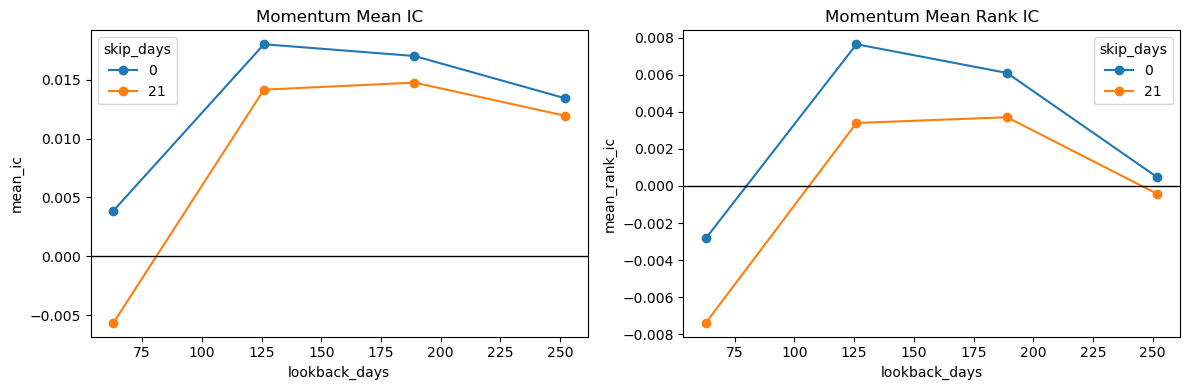

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
mean_ic_pivot.plot(marker="o", ax=axes[0], title="Momentum Mean IC")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_ylabel("mean_ic")

rank_ic_pivot.plot(marker="o", ax=axes[1], title="Momentum Mean Rank IC")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_ylabel("mean_rank_ic")

plt.tight_layout()
plt.show()

## Research Conclusion

The factor IC evidence is weak overall. Momentum is the most promising of the current factors, but the original 12-1 version is not clearly the best specification. In the tested sample, 6-month no-skip momentum appears stronger than 12-1 momentum. Low-volatility and reversal have weaker or less stable IC evidence and should be handled carefully.